<a href="https://colab.research.google.com/github/aalbudoor/AI7101-Lab2---Abdulla-Afalasi/blob/main/AI_Dengi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DengAI Predicting Disease Spread

"Insert here a brief description about the project"


## Step 1: Loading *Dataset*

In [ ]:
# Imports
import pandas as pd
import numpy as np
from typing import Tuple, List
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
train_feat   = pd.read_csv("/content/data/dengue_features_train.csv")
train_labels = pd.read_csv("/content/data/dengue_labels_train.csv")
test_feat    = pd.read_csv("/content/data/dengue_features_test.csv")


In [ ]:
# Merge features and labels to align on city/year/week
df = train_feat.merge(train_labels, on=["city", "year", "weekofyear"], how="inner")

print("Training features shape:", train_feat.shape)
print("Training labels shape:", train_labels.shape)
print("Merged dataset shape:", df.shape)

Training features shape: (1456, 24)
Training labels shape: (1456, 4)
Merged dataset shape: (1456, 25)


##Step 2: Discovering Dataset
Before preprocessing, it's important to confirm whether the dataset has
missing values (NaNs). If here are many NaNs in the numeric columns we have to decide on how we will handle them. Additionally, we need to determine whether there are any categorical features that need to be handled

In [ ]:
# Total NaNs in the dataset
total_missing = df.isna().sum().sum()
print("Total missing values in dataset:", total_missing)

# Missing values per column
missing_per_col = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column (top 15):")
print(missing_per_col.head(15))


Total missing values in dataset: 548

Missing values per column (top 15):
ndvi_ne                                 194
ndvi_nw                                  52
station_avg_temp_c                       43
station_diur_temp_rng_c                  43
ndvi_se                                  22
ndvi_sw                                  22
station_precip_mm                        22
station_max_temp_c                       20
station_min_temp_c                       14
precipitation_amt_mm                     13
reanalysis_sat_precip_amt_mm             13
reanalysis_min_air_temp_k                10
reanalysis_max_air_temp_k                10
reanalysis_relative_humidity_percent     10
reanalysis_precip_amt_kg_per_m2          10
dtype: int64


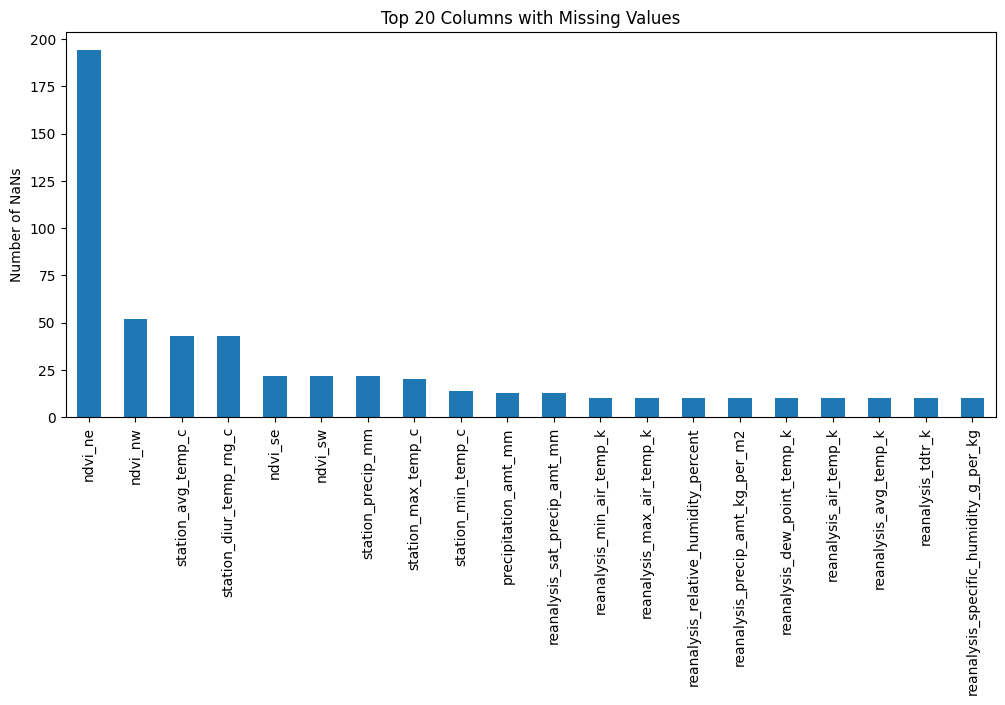

In [ ]:
import matplotlib.pyplot as plt

# Bar plot of top 20 columns with missing values
missing_per_col.head(20).plot(kind="bar", figsize=(12,5))
plt.ylabel("Number of NaNs")
plt.title("Top 20 Columns with Missing Values")
plt.show()

### Detecting Feature Types
We separate categorical and numeric features:
- Categorical
- Numeric: float/int features


In [ ]:
categorical_features = []
numeric_features = []

for col in df.columns:
    if df[col].dtype == "object":
        categorical_features.append(col)
    else:
        # Heuristic: if unique values < 10 and dtype is int, could be categorical (like 'year')
        if df[col].dtype in ["int64", "int32"] and df[col].nunique() < 10:
            categorical_features.append(col)
        else:
            numeric_features.append(col)

print("Categorical features:", categorical_features)
print("Numeric features (first 10):", numeric_features[:10])
print("Total numeric features:", len(numeric_features))

Categorical features: ['city', 'week_start_date']
Numeric features (first 10): ['year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k']
Total numeric features: 23


The only categorical feature is 'City' (week_start_date is an object however it is not a categorical feature, its a datetime object)

###Conclusion:
From this inspection, we can see that several NDVI and climate features contain missing values. This justifies the need for preprocessing steps. Additionally we found that the only categorical feature is 'city'. We will preprocess the data according to those findings.

##Step 3: Data Preprocessing


### Helper functions
- `_merge_train`: merges train features + train labels
- `_select_numeric_feature_cols`: pick numeric (continuous) columns; exclude datetime-like
- `_build_preprocessor`: OneHotEncode `city`, passthrough numeric


In [ ]:
def _merge_train(features: pd.DataFrame, labels: pd.DataFrame) -> pd.DataFrame:
    """Merge train features with labels on (city, year, weekofyear)."""
    df = features.merge(labels, on=["city", "year", "weekofyear"], how="inner")
    if df.empty:
        raise ValueError(
            "Merge produced 0 rows. Use *Training_Data_Features.csv* with *Training_Data_Labels.csv*."
        )
    return df

def _select_numeric_feature_cols(df: pd.DataFrame) -> List[str]:
    """
    Select common continuous DengAI features present in df (and keep year/weekofyear).
    Excludes datetime-like columns (e.g., week_start_date).
    """
    # Drop datetime-like from consideration
    non_dt = [c for c in df.columns if not pd.api.types.is_datetime64_any_dtype(df[c])]
    df_nd = df[non_dt]

    candidates = []
    candidates += [c for c in df_nd.columns if c.startswith("ndvi_")]
    candidates += [
        "precipitation_amt_mm",
        "reanalysis_air_temp_k",
        "reanalysis_dew_point_temp_k",
        "reanalysis_relative_humidity_percent",
        "reanalysis_sat_precip_amt_mm",
        "reanalysis_specific_humidity_g_per_kg",
        "reanalysis_max_air_temp_k",
        "reanalysis_min_air_temp_k",
        "reanalysis_precip_amt_kg_per_m2",
        "reanalysis_tdtr_k",
        "station_avg_temp_c",
        "station_diur_temp_rng_c",
        "station_max_temp_c",
        "station_min_temp_c",
        "station_precip_mm",
    ]
    # Often helpful time numerics:
    for tcol in ["year", "weekofyear"]:
        if tcol in df_nd.columns:
            candidates.append(tcol)

    return [c for c in candidates if c in df_nd.columns]

def _build_preprocessor(num_cols: List[str]) -> ColumnTransformer:
    """One-hot encode 'city' and passthrough numeric features."""
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["city"]),
            ("num", "passthrough", num_cols),
        ],
        remainder="drop"
    )


### Handling Categorical Feature: `city`

The DengAI dataset contains data from **two cities**:
- **San Juan** (`sj`)
- **Iquitos** (`iq`)

Since `city` is a **categorical variable**, ML models cannot
directly work with text labels like `"sj"` and `"iq"`. They expect numeric
inputs.

**One-hot encoding**  
   - Creates a new binary column for each category.  
   - Example:  
     ```
     city_sj  city_iq
       1        0     
       0        1     
     ```
   - No false ordering is introduced. Each category is represented separately.

For this reason, we use **`OneHotEncoder`** from scikit-learn. It automatically:
- Expands the `city` column into two binary columns.
- Ensures both train and test use the same encoded structure.
- Ignores unknown categories safely with `handle_unknown="ignore"`.

This keeps our preprocessing consistent and makes it easy for the model to handle categorical features.


In [ ]:
num_cols_demo = []  # empty list, so we only encode 'city' for now
preprocessor_demo = _build_preprocessor(num_cols_demo)

# Fit on TRAIN cities, transform both TRAIN and TEST
X_train_city = preprocessor_demo.fit_transform(train_feat[["city"]])
X_test_city  = preprocessor_demo.transform(test_feat[["city"]])

# Extract readable column names
city_ohe_cols = preprocessor_demo.named_transformers_["cat"].get_feature_names_out(["city"])

# Build small preview DataFrames
train_city_encoded_df = pd.DataFrame(X_train_city, columns=city_ohe_cols, index=train_feat.index)
test_city_encoded_df  = pd.DataFrame(X_test_city,  columns=city_ohe_cols, index=test_feat.index)

print(">>> TRAIN — BEFORE:")
display(train_feat[["city"]].head())

print(">>> TRAIN — AFTER OneHotEncoding:")
display(train_city_encoded_df.head())

print(">>> TEST — AFTER OneHotEncoding:")
display(test_city_encoded_df.head())


>>> TRAIN — BEFORE:


,city
0,sj
1,sj
2,sj
3,sj
4,sj


>>> TRAIN — AFTER OneHotEncoding:


,city_iq,city_sj
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


>>> TEST — AFTER OneHotEncoding:


,city_iq,city_sj
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


###Plan for Handling Missing Values (NaNs)

We confirmed that several NDVI and climate features contain NaNs. Our goal is to make inputs model-ready by handling those NaNs in some way.

**Strategy (two alternative pipelines):**
1. **Linear interpolation (per city)**  
   - Smoothly fills interior gaps using surrounding values, averages the previous and next entry.
   - `interpolate(method="linear", limit_direction="both")`  
   - Good for climate/NDVI series since the data is weekly they shouldn't differ greatly from the previous or next weeks, the average could be a close estimate to the real value.

2. **Forward fill (per city)**  
   - Uses the **previous** known value to fill missing entries (`ffill`).  
   - Useful for production-style setups where, at prediction time, you prefer relying on information that was already available in the **past**.



In [ ]:
def train_features_avg(
    features: pd.DataFrame,
    labels: pd.DataFrame,
    target_col: str = "total_cases"
) -> Tuple[np.ndarray, np.ndarray, ColumnTransformer, pd.DataFrame, List[str]]:
    """Preprocess TRAIN with per-city linear interpolation for numeric columns."""
    df = _merge_train(features, labels)
    numeric_cols = _select_numeric_feature_cols(df)

    def _interp_city(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()
        g[numeric_cols] = g[numeric_cols].interpolate(method="linear", limit_direction="both")
        return g

    df_proc = df.groupby("city", group_keys=False).apply(_interp_city)
    df_model = df_proc.dropna(subset=[target_col]).copy()

    preprocessor = _build_preprocessor(numeric_cols)
    X = preprocessor.fit_transform(df_model[["city"] + numeric_cols])
    y = df_model[target_col].astype(float).values

    return X, y, preprocessor, df_model, numeric_cols


def test_features_from_train_avg(
    test_features: pd.DataFrame,
    numeric_cols_from_train: List[str],
    fitted_preprocessor
) -> Tuple[np.ndarray, pd.DataFrame]:
    """Preprocess TEST with per-city linear interpolation (using TRAIN's numeric columns)."""
    test = test_features.copy()
    for col in numeric_cols_from_train:
        if col not in test.columns:
            test[col] = np.nan

    def _interp_city(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()
        g[numeric_cols_from_train] = g[numeric_cols_from_train].interpolate(
            method="linear", limit_direction="both"
        )
        return g

    test_proc = test.groupby("city", group_keys=False).apply(_interp_city)
    X_test = fitted_preprocessor.transform(test_proc[["city"] + numeric_cols_from_train])
    return X_test, test_proc

# ------------------------------
# Forward fill (ffill) functions
# ------------------------------
def train_features_ffill(
    features: pd.DataFrame,
    labels: pd.DataFrame,
    target_col: str = "total_cases"
) -> Tuple[np.ndarray, np.ndarray, ColumnTransformer, pd.DataFrame, List[str]]:
    """Preprocess TRAIN with per-city forward fill for numeric columns."""
    df = _merge_train(features, labels)
    numeric_cols = _select_numeric_feature_cols(df)

    def _ffill_city(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()
        g[numeric_cols] = g[numeric_cols].ffill()
        return g

    df_proc = df.groupby("city", group_keys=False).apply(_ffill_city)
    df_model = df_proc.dropna(subset=[target_col]).copy()

    preprocessor = _build_preprocessor(numeric_cols)
    X = preprocessor.fit_transform(df_model[["city"] + numeric_cols])
    y = df_model[target_col].astype(float).values

    return X, y, preprocessor, df_model, numeric_cols


def test_features_from_train_ffill(
    test_features: pd.DataFrame,
    numeric_cols_from_train: List[str],
    fitted_preprocessor
) -> Tuple[np.ndarray, pd.DataFrame]:
    """Preprocess TEST with per-city forward fill (using TRAIN's numeric columns)."""
    test = test_features.copy()
    for col in numeric_cols_from_train:
        if col not in test.columns:
            test[col] = np.nan

    def _ffill_city(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()
        g[numeric_cols_from_train] = g[numeric_cols_from_train].ffill()
        return g

    test_proc = test.groupby("city", group_keys=False).apply(_ffill_city)
    X_test = fitted_preprocessor.transform(test_proc[["city"] + numeric_cols_from_train])
    return X_test, test_proc

In [ ]:
# --- Linear interpolation path ---
X_avg, y_avg, preproc_avg, df_avg, num_cols_avg = train_features_avg(
    train_feat, train_labels, target_col="total_cases"
)
print("TRAIN (linear interpolation):", X_avg.shape, y_avg.shape)

X_test_avg, test_avg_proc = test_features_from_train_avg(
    test_feat, numeric_cols_from_train=num_cols_avg, fitted_preprocessor=preproc_avg
)
print("TEST  (linear interpolation):", X_test_avg.shape)

# --- Forward fill path ---
X_ffill, y_ffill, preproc_ffill, df_ffill, num_cols_ffill = train_features_ffill(
    train_feat, train_labels, target_col="total_cases"
)
print("TRAIN (forward fill):", X_ffill.shape, y_ffill.shape)

X_test_ffill, test_ffill_proc = test_features_from_train_ffill(
    test_feat, numeric_cols_from_train=num_cols_ffill, fitted_preprocessor=preproc_ffill
)
print("TEST  (forward fill):", X_test_ffill.shape)


TRAIN (linear interpolation): (1456, 23) (1456,)
TEST  (linear interpolation): (416, 23)
TRAIN (forward fill): (1456, 23) (1456,)
TEST  (forward fill): (416, 23)


/tmp/ipython-input-3682158609.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_proc = df.groupby("city", group_keys=False).apply(_interp_city)
/tmp/ipython-input-3682158609.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_proc = test.groupby("city", group_keys=False).apply(_interp_city)
/tmp/ipython-input-3682158609.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping c

In [ ]:
def get_feature_names(preprocessor, num_cols):
    cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(["city"]).tolist()
    return cat_names + num_cols

# Linear interpolation
print("=== Linear Interpolation ===")
print("TRAIN (X_avg, y_avg):", X_avg.shape, y_avg.shape)
print("TEST  (X_test_avg): ", X_test_avg.shape)

feat_names_avg = get_feature_names(preproc_avg, num_cols_avg)
print("\nFeature names (avg):")
print(feat_names_avg)

# Forward fill
print("\n=== Forward Fill ===")
print("TRAIN (X_ffill, y_ffill):", X_ffill.shape, y_ffill.shape)
print("TEST  (X_test_ffill):   ", X_test_ffill.shape)

feat_names_ffill = get_feature_names(preproc_ffill, num_cols_ffill)
print("\nFeature names (ffill):")
print(feat_names_ffill)

# Optional: preview first 5 rows of TRAIN arrays as DataFrames
import pandas as pd

print("\n>>> Preview TRAIN (avg):")
display(pd.DataFrame(X_avg[:5], columns=feat_names_avg))

print("\n>>> Preview TRAIN (ffill):")
display(pd.DataFrame(X_ffill[:5], columns=feat_names_ffill))


=== Linear Interpolation ===
TRAIN (X_avg, y_avg): (1456, 23) (1456,)
TEST  (X_test_avg):  (416, 23)

Feature names (avg):
['city_iq', 'city_sj', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm', 'year', 'weekofyear']

=== Forward Fill ===
TRAIN (X_ffill, y_ffill): (1456, 23) (1456,)
TEST  (X_test_ffill):    (416, 23)

Feature names (ffill):
['city_iq', 'city_sj', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_h

,city_iq,city_sj,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_dew_point_temp_k,reanalysis_relative_humidity_percent,...,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,year,weekofyear
0,0.0,1.0,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,292.414286,73.365714,...,295.9,32.00,2.628571,25.442857,6.900000,29.4,20.0,16.0,1990.0,18.0
1,0.0,1.0,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,293.951429,77.368571,...,296.4,17.94,2.371429,26.714286,6.371429,31.7,22.2,8.6,1990.0,19.0
2,0.0,1.0,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,295.434286,82.052857,...,297.3,26.10,2.300000,26.714286,6.485714,32.2,22.8,41.4,1990.0,20.0
3,0.0,1.0,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,295.310000,80.337143,...,297.0,13.90,2.428571,27.471429,6.771429,33.3,23.3,4.0,1990.0,21.0
4,0.0,1.0,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,295.821429,80.460000,...,297.5,12.20,3.014286,28.942857,9.371429,35.0,23.9,5.8,1990.0,22.0



>>> Preview TRAIN (ffill):


,city_iq,city_sj,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_dew_point_temp_k,reanalysis_relative_humidity_percent,...,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,year,weekofyear
0,0.0,1.0,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,292.414286,73.365714,...,295.9,32.00,2.628571,25.442857,6.900000,29.4,20.0,16.0,1990.0,18.0
1,0.0,1.0,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,293.951429,77.368571,...,296.4,17.94,2.371429,26.714286,6.371429,31.7,22.2,8.6,1990.0,19.0
2,0.0,1.0,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,295.434286,82.052857,...,297.3,26.10,2.300000,26.714286,6.485714,32.2,22.8,41.4,1990.0,20.0
3,0.0,1.0,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,295.310000,80.337143,...,297.0,13.90,2.428571,27.471429,6.771429,33.3,23.3,4.0,1990.0,21.0
4,0.0,1.0,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,295.821429,80.460000,...,297.5,12.20,3.014286,28.942857,9.371429,35.0,23.9,5.8,1990.0,22.0


In [ ]:
def check_nans(name, arr):
    if np.isnan(arr).any():
        print(f"⚠️ NaNs found in {name}")
    else:
        print(f"✅ No NaNs in {name}")

# Linear interpolation sets
check_nans("X_avg", X_avg)
check_nans("y_avg", y_avg)
check_nans("X_test_avg", X_test_avg)

# Forward fill sets
check_nans("X_ffill", X_ffill)
check_nans("y_ffill", y_ffill)
check_nans("X_test_ffill", X_test_ffill)

✅ No NaNs in X_avg
✅ No NaNs in y_avg
✅ No NaNs in X_test_avg
✅ No NaNs in X_ffill
✅ No NaNs in y_ffill
✅ No NaNs in X_test_ffill


###Conclusion: Preprocessed Datasets Overview

We now have **two complete preprocessing pipelines** for the DengAI dataset, each handling missing values differently. Both pipelines output the same **23 features** (including one-hot encoded `city`).

### Variables Produced

- **Linear Interpolation Pipeline**
  - `X_avg` → Training features (1456 × 23), NaNs filled by linear interpolation per city.  
  - `y_avg` → Training labels (1456,), number of dengue cases.  
  - `X_test_avg` → Test features (416 × 23), processed with the same interpolation strategy.  
  - `preproc_avg` → Preprocessor object (OneHotEncoder + passthrough), ensures consistent encoding for train/test.  
  - `num_cols_avg` → List of numeric feature names used in this pipeline.  
  - `df_avg` → Processed train DataFrame (with interpolated numeric values).

- **Forward Fill Pipeline**
  - `X_ffill` → Training features (1456 × 23), NaNs filled by carrying forward the previous value per city.  
  - `y_ffill` → Training labels (1456,), number of dengue cases.  
  - `X_test_ffill` → Test features (416 × 23), processed with the same forward fill strategy.  
  - `preproc_ffill` → Preprocessor object for this pipeline.  
  - `num_cols_ffill` → List of numeric feature names used here.  
  - `df_ffill` → Processed train DataFrame (with forward-filled numeric values).

### Why Two Pipelines?
- **Linear interpolation** assumes climate/NDVI signals change gradually, so the average of surrounding weeks is a reasonable estimate.  
- **Forward fill** is more conservative: it only uses past information, which is safer for time-series prediction (no future leakage).  

### Key Points
- Both pipelines include **23 features** (21 numeric + 2 one-hot encoded city columns).  
- Train sets: **1456 rows**, Test sets: **416 rows**.  
- After preprocessing, **no NaNs remain** in any train/test arrays.  
- Feature matrices and labels are now ready for modeling

Both sets (X_avg/y_avg and X_ffill/y_ffill) are now ready for modeling, having the same dimensions and feature columns. In practice, you could experiment with both and see which yields better validation performance.

# **Building a Random Forest Regressor**
Train/Validation with TimeSeriesSplit

*   Train/Validation with TimeSeriesSplit: Use cross-validation with a strategy like TimeSeriesSplit (from sklearn.model_selection) to perform multiple sequential train/validation splits without shuffling. This will train on early weeks and validate on later weeks repeatedly, giving a more robust estimate of performance.

*   Initialize the Random Forest: Set up a RandomForestRegressor from scikit-learn.


*   Fit the Model: Train the random forest on the training data.

*   Evaluate Performance: After training, evaluate the model on the validation set or via cross-validation


*   Hyperparameter Tuninng

*   Feature Importance (Additional Analysis)



*   Train Final Model on Full Data: Once you’ve selected the best-performing strategy and hyperparameters (e.g., you determined forward-fill with certain parameters works best), retrain the model on all available training data (all 1456 observations). This way, the model learns from the maximum data before making final predictions.

*   Predict on Test Set: Use the final model to predict dengue cases for the test features.





## Train/Validation with TimeSeriesSplit

In [53]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error
from scipy.stats import randint

In [58]:
# -----------------------------
# Choose dataset (forward fill recommended)
# -----------------------------
X, y = X_ffill, y_ffill
# Or: X, y = X_avg, y_avg

# -----------------------------
# Define TimeSeriesSplit
# -----------------------------
tscv = TimeSeriesSplit(n_splits=5)

# -----------------------------
# Define model
# -----------------------------
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# -----------------------------
# Hyperparameter grid
# -----------------------------
# param_grid = {
#     "n_estimators": [100, 200, 300],    # number of trees
#     "max_depth": [5, 10, 15, None],     # depth of trees
#     "min_samples_split": [2, 5, 10],    # minimum samples to split node
#     "min_samples_leaf": [1, 2, 5],      # minimum samples per leaf
#     "max_features": ["sqrt", "log2", None]  # number of features considered
# }

# -----------------------------
# Hyperparameter distributions
# -----------------------------
param_dist = {
    "n_estimators": randint(100, 600),        # random between 100 and 600
    "max_depth": [5, 10, 15, 20, None],      # fixed list
    "min_samples_split": randint(2, 15),     # random int between 2 and 15
    "min_samples_leaf": randint(1, 10),      # random int between 1 and 10
    "max_features": ["sqrt", "log2", None]   # categorical choices
}


# -----------------------------
# Define scorer (MAE)
# -----------------------------
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# -----------------------------
# GridSearchCV
# -----------------------------
# grid_search = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     scoring=mae_scorer,
#     cv=tscv,
#     n_jobs=-1,
#     verbose=2
# )


# Fit grid search
# grid_search.fit(X, y)

# -----------------------------
# RandomizedSearchCV
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,               # number of random combos to try
    scoring=mae_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Fit random search for faster approximation as opposed to Fit grid search
random_search.fit(X, y)

# -----------------------------
# Results
# -----------------------------
# print("Best Parameters:", grid_search.best_params_)
# print("Best CV MAE:", -grid_search.best_score_)

print("Best Parameters:", random_search.best_params_)
print("Best CV MAE:", -random_search.best_score_)

# -----------------------------
# Cross-validation
# -----------------------------
cv_scores = cross_val_score(rf, X, y, cv=tscv, scoring=mae_scorer)

print("Cross-validation MAE scores:", -cv_scores)
print("Mean MAE:", -cv_scores.mean())
print("Std dev:", cv_scores.std())

# the fitted model
# best_rf = grid_search.best_estimator_
# or
best_rf = random_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 4, 'n_estimators': 305}
Best CV MAE: 22.135825758466353
Cross-validation MAE scores: [49.9835124  37.51136364 21.23504132  8.82570248  8.32690083]
Mean MAE: 25.176504132231408
Std dev: 16.336030076835243


## Feature Importance:
After fitting the model, you can examine which features the random forest found important. Scikit-learn’s feature_importances_ attribute gives an importance score for each feature. This can inform you which climate or NDVI factors are most predictive of dengue cases.

In [59]:
feat_names = get_feature_names(preproc_ffill, num_cols_ffill)  # reuse function to get col names
importances = pd.Series(best_rf.feature_importances_, index=feat_names)
print(importances.sort_values(ascending=False).head(10))

ndvi_se                        0.303287
year                           0.250691
ndvi_sw                        0.150196
weekofyear                     0.126512
reanalysis_air_temp_k          0.046414
reanalysis_dew_point_temp_k    0.015805
reanalysis_min_air_temp_k      0.015515
reanalysis_max_air_temp_k      0.013576
ndvi_ne                        0.013249
reanalysis_tdtr_k              0.010375
dtype: float64


## Train Final Model on Full Data:

Once you’ve selected the best-performing strategy and hyperparameters (e.g., you determined forward-fill with certain parameters works best), retrain the model on all available training data (all 1456 observations). This way, the model learns from the maximum data before making final predictions.

In [61]:
# -----------------------------
# Train final model on ALL training data
# -----------------------------
best_params = random_search.best_params_

final_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

# Use forward fill dataset (recommended)
X, y = X_ffill, y_ffill
final_rf.fit(X, y)

print("Final model trained on full data.")

Final model trained on full data.


## Predict on Test Set


Use the final model to predict dengue cases for the test features.

In [62]:
# Pick the matching processed test set
X_test = X_test_ffill   # if you trained on X_ffill
# Or: X_test = X_test_avg

test_preds = final_rf.predict(X_test)

# Predictions are floats → round or clip if needed
test_preds = np.round(test_preds).astype(int)
test_preds = np.clip(test_preds, 0, None)  # no negative cases

print("Test predictions (first 10):", test_preds[:10])

Test predictions (first 10): [ 4  5  6  6  8 10 11 12 20 17]


## Compare Validation MAE



1.   Evaluate the final trained model (on all data) with a held-out validation set.

2.   Compare with the cross-validation MAE you already got from RandomizedSearchCV or GridSearchCV.





In [63]:
# Use forward-fill dataset (recommended)
X, y = X_ffill, y_ffill

# Simple time-aware split: 80% train, 20% validation
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# Retrain model with best params on training portion
final_rf_valcheck = RandomForestRegressor(
    **random_search.best_params_,   # or grid_search.best_params_
    random_state=42,
    n_jobs=-1
)
final_rf_valcheck.fit(X_train, y_train)

# Validation predictions
val_preds = final_rf_valcheck.predict(X_val)

# Compute MAE
val_mae = mean_absolute_error(y_val, val_preds)
print("Validation MAE (hold-out set):", val_mae)

# Cross-validation score (already from random_search or grid_search)
cv_mae = -random_search.best_score_   # negative turned positive
print("Cross-validation MAE (avg over folds):", cv_mae)

print("\nComparison:")
print(f"- Cross-validation mean MAE: {cv_mae:.2f}")
print(f"- Hold-out validation MAE:   {val_mae:.2f}")

Validation MAE (hold-out set): 7.881975644197904
Cross-validation MAE (avg over folds): 22.135825758466353

Comparison:
- Cross-validation mean MAE: 22.14
- Hold-out validation MAE:   7.88
